# 🎒 Backpack Price Prediction: EDA & CatBoost Regression

## 🎯 Projenin Amacı

Bu çalışma, Kaggle Playground Series S5E2 kapsamında, sırt çantalarının çeşitli fiziksel, fonksiyonel ve marka özelliklerine dayanarak piyasa satış fiyatlarını (Price) tahmin etmektir. Veri seti 300.000 gözlemden oluşmakta olup; çantaların üretim materyallerinden taşıma kapasitelerine, bölme sayılarından su geçirmezlik durumlarına kadar hem sayısal hem de kategorik birçok değişkeni içermektedir.

Fiyatı belirleyen temel unsurlar arasında marka değeri (Brand), taşıma kapasitesi (Weight Capacity) ve fonksiyonellik (Laptop Compartment, Compartments) gibi özelliklerin kritik bir rol oynaması beklenmektedir. Bu faktörler arasındaki hem doğrusal hem de karmaşık doğrusal olmayan ilişkileri yakalamak, doğru bir fiyatlandırma modeli kurmak için hayati önem taşır.

Bu problem bir regresyon görevi olarak kurgulanmıştır. Sürekli bir hedef değişken olan Price değerini en hassas şekilde tahmin etmek amacıyla bu notebook'ta şu adımlar izlenecektir:

**Keşifçi Veri Analizi (EDA):** Veri setindeki dağılımların, aykırı değerlerin ve özellikler arasındaki korelasyonların incelenmesi.

**Veri Ön İşleme ve Özellik Mühendisliği (Feature Engineering):** Kategorik verilerin anlamlandırılması (Target Encoding) ve değişkenler arası etkileşimlerin (Material-Size vb.) modele dahil edilmesi.

**Model Eğitimi ve Karşılaştırma:** Özellikle kategorik verilerde yüksek performans sergileyen CatBoost algoritmasının uygulanması.

**Hata Analizi ve Değerlendirme:** Modelin tahmin performansının (RMSE) ölçülmesi ve hataların karakteristiğinin (Residuals Plot) analiz edilmesi.


### Veri Sözlüğü

| Değişken İsmi | Açıklama |
| --- | --- |
| **Brand** | Çantanın üretici markası (Örn: Nike, Adidas, Jansport). Marka algısı fiyatı doğrudan etkiler. |
| **Material** | Çantanın yapıldığı ana malzeme (Deri, Kanvas, Naylon, Polyester). Dayanıklılık ve maliyet belirleyicidir. |
| **Size** | Çantanın fiziksel boyutu (Küçük, Orta, Büyük). Kullanım amacını belirler. |
| **Compartments** | Çantadaki toplam bölme sayısı. Fonksiyonelliği ve düzenleme kapasitesini gösterir. |
| **Laptop Compartment** | Laptop için özel korumalı bir bölme olup olmadığı (Evet/Hayır). |
| **Waterproof** | Çantanın su geçirmezlik özelliği olup olmadığı. Dış mekan kullanımı için kritik bir özelliktir. |
| **Style** | Çantanın tasarımı (Sırt çantası, Postacı çantası, Tote). Stil, hedef kitleyi belirler. |
| **Color** | Çantanın rengi. Estetik tercihleri ve pazar trendlerini yansıtır. |
| **Weight Capacity (kg)** | Çantanın güvenle taşıyabileceği maksimum ağırlık. Yapısal sağlamlığın göstergesidir. |
| **Price (Target)** | **Hedef Değişken.** Çantanın piyasadaki satış fiyatı. |


<img src='https://dynamic-media-cdn.tripadvisor.com/media/photo-o/1c/a5/4a/cd/leather-backpacks.jpg?w=900&h=500&s=1' width=600>

In [1]:
# pandas → veri okuma, düzenleme ve tablo (DataFrame) işlemleri için kullanılır
import pandas as pd

# numpy → sayısal işlemler ve matematiksel hesaplamalar için kullanılır
import numpy as np

# warnings → gereksiz uyarıları gizlemek için kullanılır
import warnings
warnings.filterwarnings('ignore')

# matplotlib → grafik çizmek için temel kütüphane
import matplotlib.pyplot as plt

# seaborn → daha estetik ve gelişmiş veri görselleştirme kütüphanesi
import seaborn as sns

In [2]:
# Verileri okuma
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# EDA

In [3]:
#ilk 5 satır göster
train.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


In [4]:
#son 5 satır göster
train.tail()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
299995,299995,Adidas,Leather,Small,9.0,No,No,Tote,Blue,12.730812,129.99749
299996,299996,Jansport,Leather,Large,6.0,No,Yes,Tote,Blue,26.633182,19.85819
299997,299997,Puma,Canvas,Large,9.0,Yes,Yes,Backpack,Pink,11.898250,111.41364
299998,299998,Adidas,Nylon,Small,1.0,No,Yes,Tote,Pink,6.175738,115.89080
299999,299999,Under Armour,Canvas,Small,2.0,No,Yes,Backpack,Black,18.568865,26.72762


In [5]:
#train dosyası veri bilgileri
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  object 
 2   Material              291653 non-null  object 
 3   Size                  293405 non-null  object 
 4   Compartments          300000 non-null  float64
 5   Laptop Compartment    292556 non-null  object 
 6   Waterproof            292950 non-null  object 
 7   Style                 292030 non-null  object 
 8   Color                 290050 non-null  object 
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB


In [6]:
#test dosyası veri bilgileri
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    200000 non-null  int64  
 1   Brand                 193773 non-null  object 
 2   Material              194387 non-null  object 
 3   Size                  195619 non-null  object 
 4   Compartments          200000 non-null  float64
 5   Laptop Compartment    195038 non-null  object 
 6   Waterproof            195189 non-null  object 
 7   Style                 194847 non-null  object 
 8   Color                 193215 non-null  object 
 9   Weight Capacity (kg)  199923 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 15.3+ MB


In [7]:
#test dosyası eksik değer kontrolü
test.isnull().sum()

id                         0
Brand                   6227
Material                5613
Size                    4381
Compartments               0
Laptop Compartment      4962
Waterproof              4811
Style                   5153
Color                   6785
Weight Capacity (kg)      77
dtype: int64

In [8]:
#train dosyası kaç satır kaç sütun
train.shape

(300000, 11)

In [9]:
#train dosyası eksik değer kontrolü
train.isnull().sum()

id                         0
Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64

In [10]:
#veriler arası istatiksel bilgi
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,300000.0,149999.500000,86602.684716,0.0,74999.750000,149999.500000,224999.250000,299999.0
Compartments,300000.0,5.443590,2.890766,1.0,3.000000,5.000000,8.000000,10.0
Weight Capacity (kg),299862.0,18.029994,6.966914,5.0,12.097867,18.068614,24.002375,30.0
Price,300000.0,81.411107,39.039340,15.0,47.384620,80.956120,115.018160,150.0


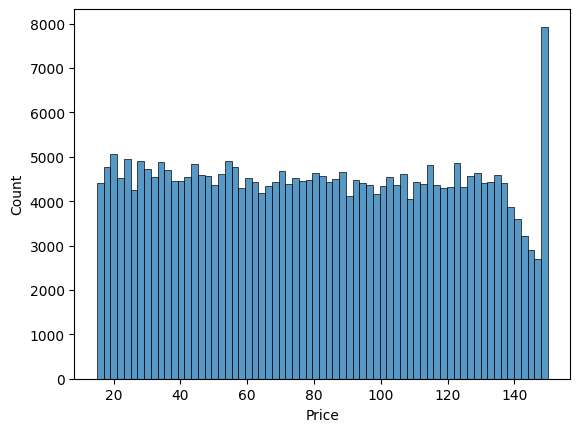

In [11]:
# Hedef değişken (Price) dağılımı
sns.histplot(train['Price'])
plt.show()

In [12]:
# Analiz edilecek kategorik sütunlar
cat_cols = ['Brand', 'Material', 'Size', 'Laptop Compartment', 'Waterproof', 'Style', 'Color']

for col in cat_cols:
    print(f"--- {col} Değer Dağılımı ---")
    print(train[col].value_counts())
    print("\n")

--- Brand Değer Dağılımı ---
Brand
Adidas          60077
Under Armour    59992
Nike            57336
Puma            56814
Jansport        56076
Name: count, dtype: int64


--- Material Değer Dağılımı ---
Material
Polyester    79630
Leather      73416
Nylon        70603
Canvas       68004
Name: count, dtype: int64


--- Size Değer Dağılımı ---
Size
Medium    101906
Large      98643
Small      92856
Name: count, dtype: int64


--- Laptop Compartment Değer Dağılımı ---
Laptop Compartment
Yes    148342
No     144214
Name: count, dtype: int64


--- Waterproof Değer Dağılımı ---
Waterproof
Yes    148077
No     144873
Name: count, dtype: int64


--- Style Değer Dağılımı ---
Style
Messenger    100031
Tote          97438
Backpack      94561
Name: count, dtype: int64


--- Color Değer Dağılımı ---
Color
Pink     51690
Gray     50280
Blue     48097
Red      47219
Green    46386
Black    46378
Name: count, dtype: int64




In [40]:
# Her stilin fiyat ortalamasını sözlük olarak verir
print(train.groupby('Style')['Price'].mean().to_dict())

{'Backpack': 81.40251254661013, 'Messenger': 81.41092501514531, 'Tote': 81.37486537223671, 'Unknown': 81.95843009410288}


In [41]:
# Her rengin fiyat ortalamasını sözlük olarak verir
print(train.groupby('Color')['Price'].mean().to_dict())

{'Black': 80.51343938677822, 'Blue': 82.00699402519908, 'Gray': 80.85197070127288, 'Green': 82.3813077544949, 'Pink': 81.63086430547496, 'Red': 81.01164441199516, 'Unknown': 81.7713290241206}


In [42]:
# Her markanın fiyat ortalamasını sözlük olarak verir
print(train.groupby('Brand')['Price'].mean().to_dict())

{'Adidas': 80.63106006158763, 'Jansport': 81.79127646033953, 'Nike': 81.31920949891865, 'Puma': 81.4486071033548, 'Under Armour': 81.97631096929591, 'Unknown': 80.87274884286451}


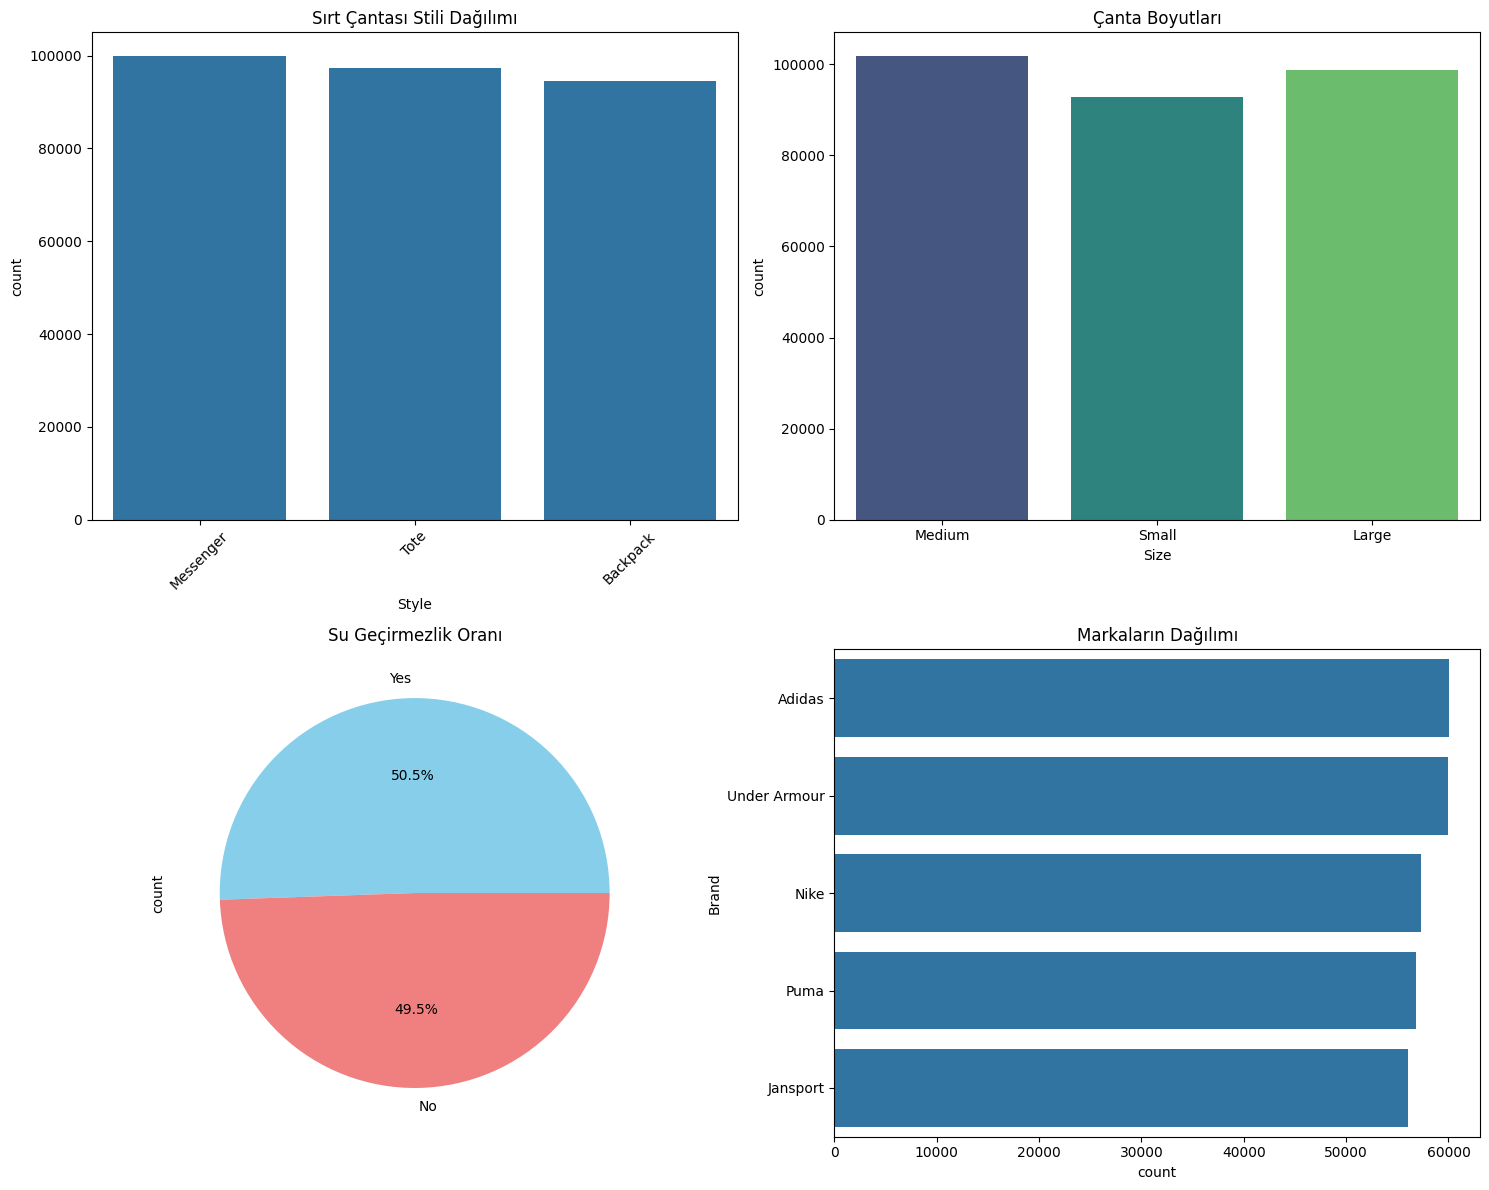

In [13]:
# Grafiklerin genel boyutu
plt.figure(figsize=(15, 12))

# 1. Stil Dağılımı
plt.subplot(2, 2, 1)
sns.countplot(data=train, x='Style', order=train['Style'].value_counts().index)
plt.title('Sırt Çantası Stili Dağılımı')
plt.xticks(rotation=45)

# 2. Boyut Dağılımı
plt.subplot(2, 2, 2)
sns.countplot(data=train, x='Size', palette='viridis')
plt.title('Çanta Boyutları')

# 3. Su Geçirmezlik Durumu
plt.subplot(2, 2, 3)
train['Waterproof'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Su Geçirmezlik Oranı')

# 4. Marka Dağılımı
plt.subplot(2, 2, 4)
sns.countplot(data=train, y='Brand', order=train['Brand'].value_counts().index)
plt.title('Markaların Dağılımı')

plt.tight_layout()
plt.show()

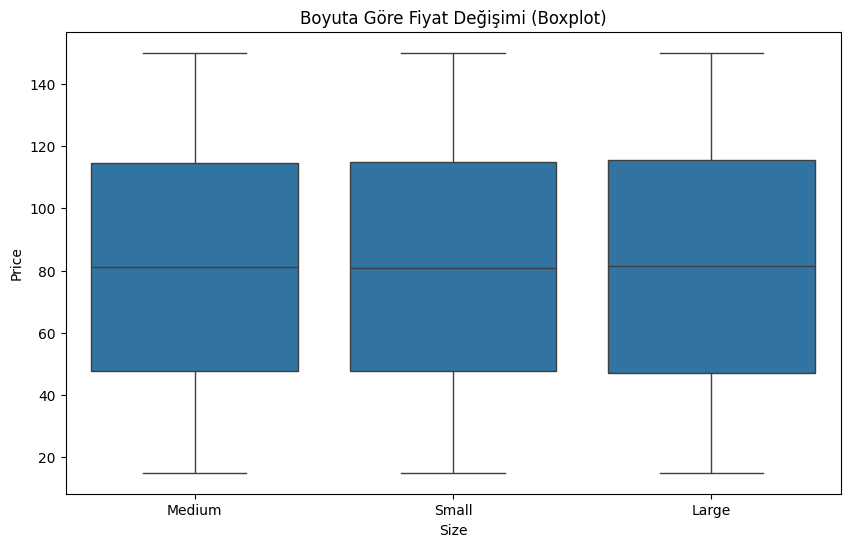

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='Size', y='Price')
plt.title('Boyuta Göre Fiyat Değişimi (Boxplot)')
plt.show()

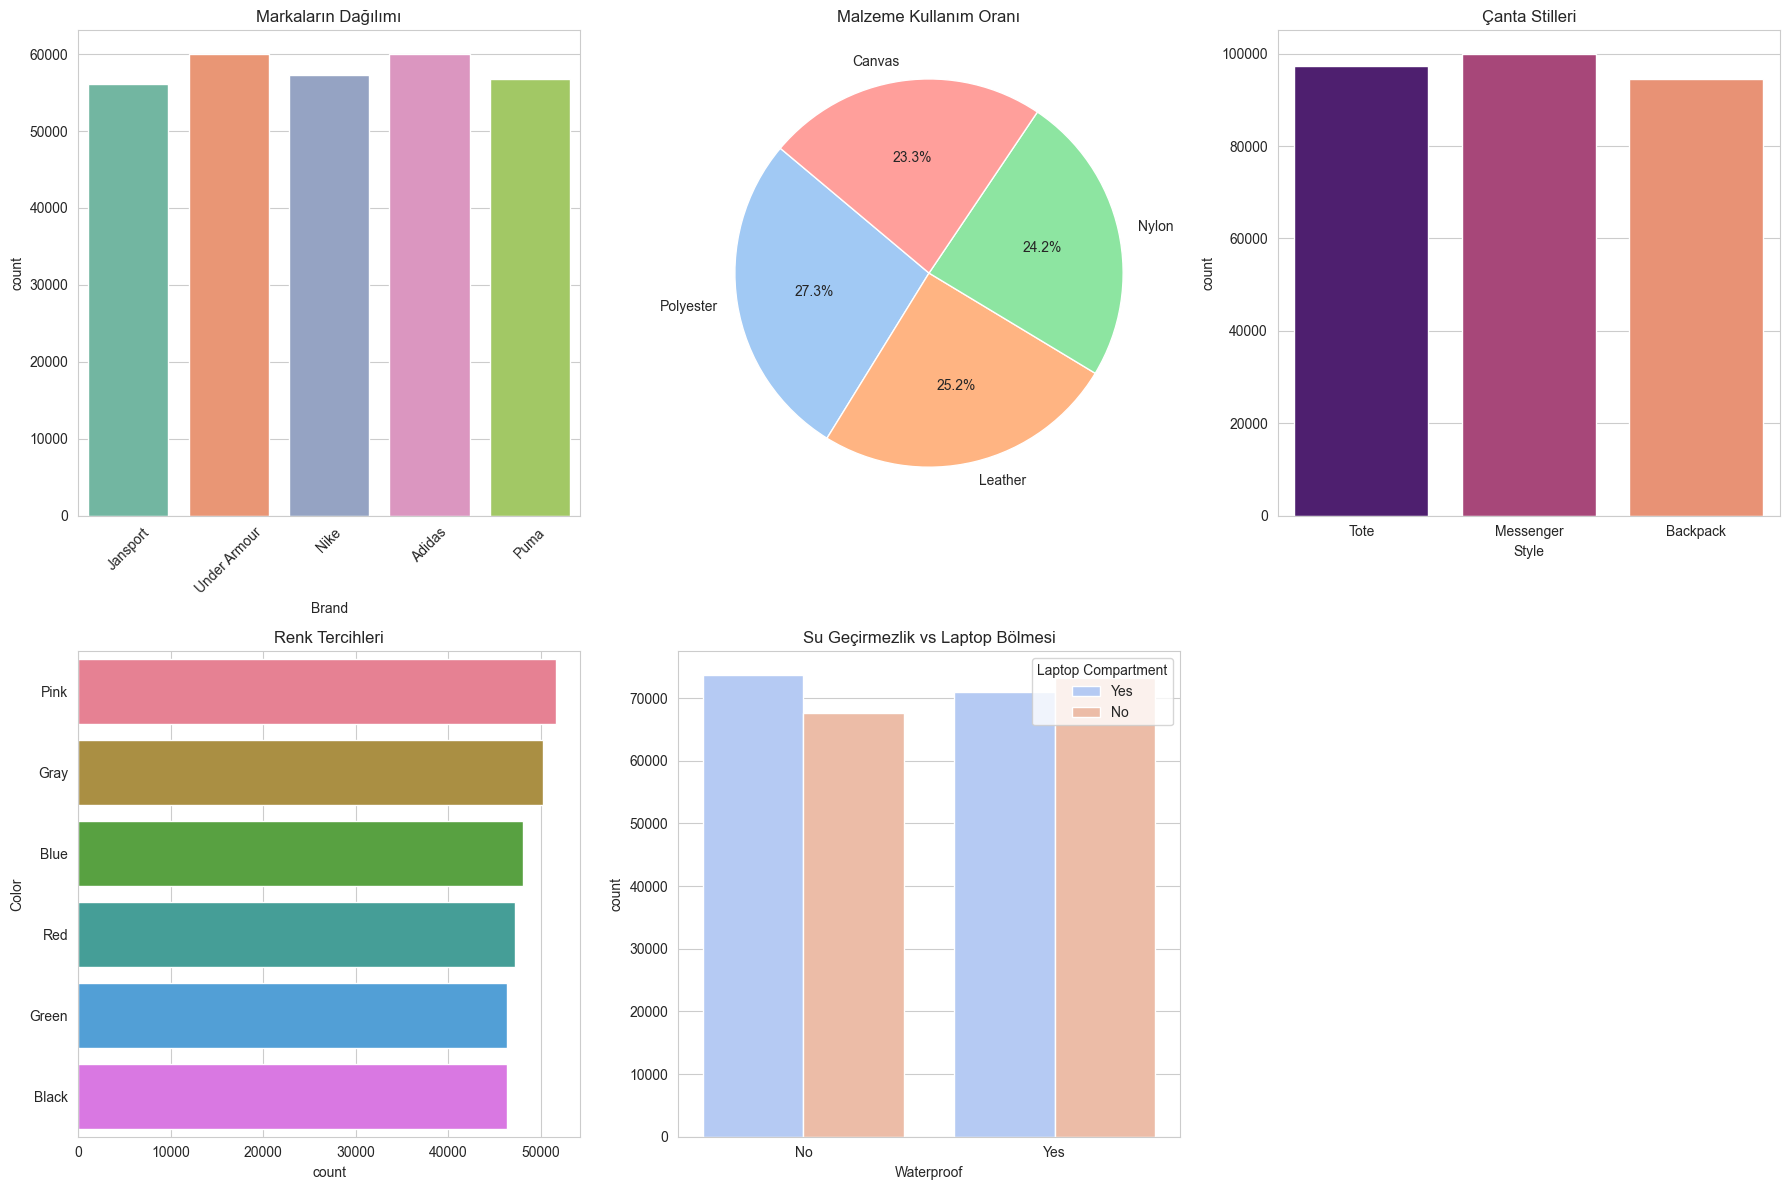

In [15]:
# Grafiklerin genel stilini ayarlayalım
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12))

# 1. Marka Dağılımı (Bar Plot)
plt.subplot(2, 3, 1)
sns.countplot(data=train, x='Brand', palette='Set2')
plt.title('Markaların Dağılımı')
plt.xticks(rotation=45)

# 2. Malzeme Dağılımı (Pie Chart)
plt.subplot(2, 3, 2)
train['Material'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Malzeme Kullanım Oranı')
plt.ylabel('')

# 3. Stil Dağılımı (Bar Plot)
plt.subplot(2, 3, 3)
sns.countplot(data=train, x='Style', palette='magma')
plt.title('Çanta Stilleri')

# 4. Renk Dağılımı (Horizontal Bar Plot)
plt.subplot(2, 3, 4)
sns.countplot(data=train, y='Color', order=train['Color'].value_counts().index, palette='husl')
plt.title('Renk Tercihleri')

# 5. Su Geçirmezlik ve Laptop Bölmesi (Dengeli mi?)
plt.subplot(2, 3, 5)
sns.countplot(data=train, x='Waterproof', hue='Laptop Compartment', palette='coolwarm')
plt.title('Su Geçirmezlik vs Laptop Bölmesi')

plt.tight_layout()
plt.show()


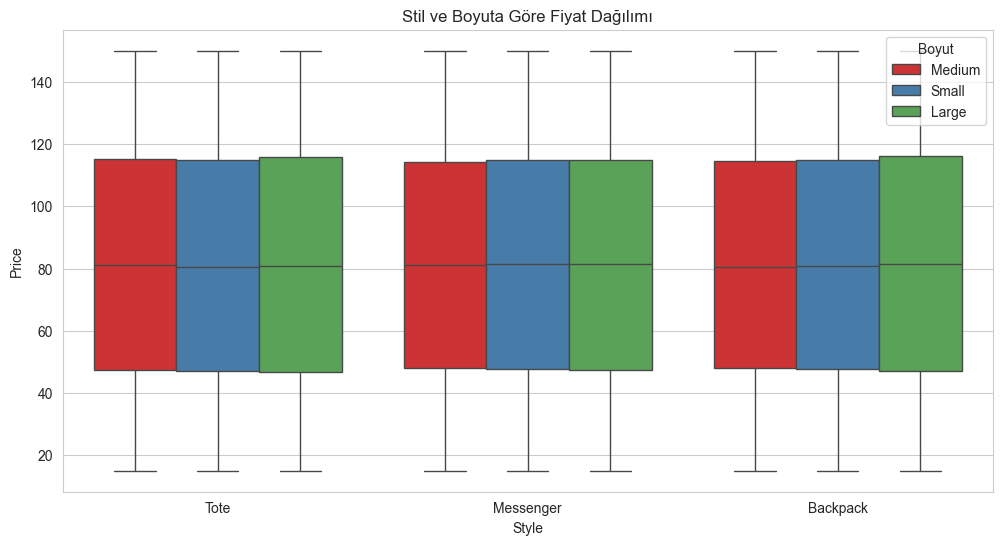

In [16]:
plt.figure(figsize=(12, 6))

# Çantanın stili ve boyutu fiyatı nasıl değiştiriyor?
sns.boxplot(data=train, x='Style', y='Price', hue='Size', palette='Set1')
plt.title('Stil ve Boyuta Göre Fiyat Dağılımı')
plt.legend(title='Boyut', loc='upper right')
plt.show()

In [17]:
# Malzemeye göre fiyat istatistikleri
material_stats = train.groupby('Material')['Price'].agg(['mean', 'std', 'count']).sort_values(by='mean', ascending=False)

In [18]:
material_stats

,mean,std,count
Material,,,
Canvas,82.106511,38.997844,68004
Polyester,82.033315,39.086462,79630
Nylon,81.024760,38.892243,70603
Leather,80.437883,39.092056,73416


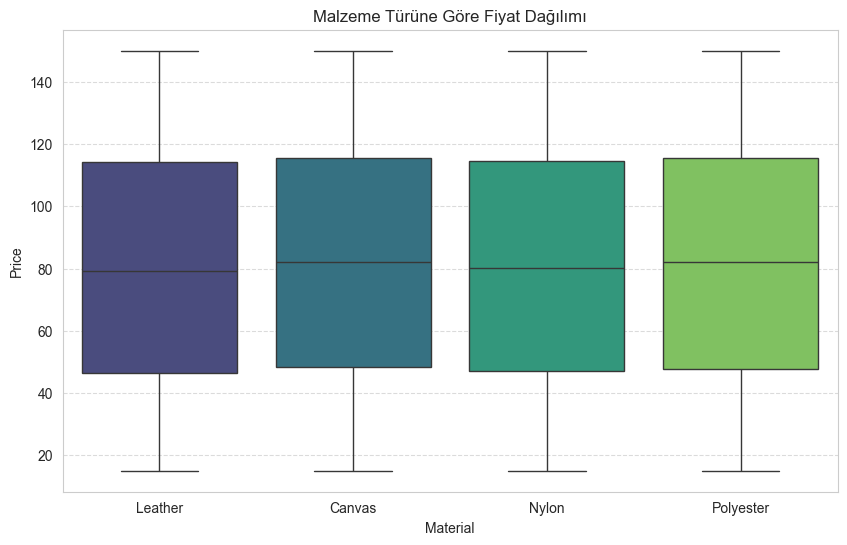

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='Material', y='Price', palette='viridis')
plt.title('Malzeme Türüne Göre Fiyat Dağılımı')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
# Kategorik eksikleri 'Unknown' ile doldur
cat_cols = ['Brand', 'Material', 'Size', 'Laptop Compartment', 'Waterproof', 'Style', 'Color']
for col in cat_cols:
    train[col] = train[col].fillna('Unknown')
    test[col] = test[col].fillna('Unknown')

In [21]:
# Sayısal eksikleri median ile doldur
train['Weight Capacity (kg)'] = train['Weight Capacity (kg)'].fillna(train['Weight Capacity (kg)'].median())
test['Weight Capacity (kg)'] = test['Weight Capacity (kg)'].fillna(test['Weight Capacity (kg)'].median())

# Feature Engineering

In [22]:
# Malzeme ve Su Geçirmezlik ilişkisini birleştiren yeni bir özellik
train['Material_Waterproof'] = train['Material'] + "_" + train['Waterproof']
test['Material_Waterproof'] = test['Material'] + "_" + test['Waterproof']

In [23]:
# Malzeme ve Boyut ilişkisi
train['Material_Size'] = train['Material'] + "_" + train['Size']
test['Material_Size'] = test['Material'] + "_" + test['Size']

In [24]:
# Material ve Size birleşiminin ortalamalarını verir
print(train.groupby('Material_Size')['Price'].mean().to_dict())

{'Canvas_Large': 82.41245874389116, 'Canvas_Medium': 81.86560958211338, 'Canvas_Small': 82.27835167065223, 'Canvas_Unknown': 78.461345907173, 'Leather_Large': 80.87535848915483, 'Leather_Medium': 80.23735904322216, 'Leather_Small': 80.52569880548793, 'Leather_Unknown': 75.84973011049723, 'Nylon_Large': 81.08649081141772, 'Nylon_Medium': 81.02408682060465, 'Nylon_Small': 81.00997647399376, 'Nylon_Unknown': 80.37032494604317, 'Polyester_Large': 82.13914081193775, 'Polyester_Medium': 82.23209006393161, 'Polyester_Small': 81.81217396029938, 'Polyester_Unknown': 80.48390155191873, 'Unknown_Large': 82.30837142551675, 'Unknown_Medium': 81.11979189407225, 'Unknown_Small': 82.04538564191802, 'Unknown_Unknown': 67.59690798076923}


In [25]:
# Hedef sütunlarımızı belirleyelim
target_cols = ['Brand', 'Style', 'Material_Size', 'Color']

for col in target_cols:
    # 1. Sadece TRAIN verisi üzerinden ortalamaları hesapla
    means = train.groupby(col)['Price'].mean()
    
    # 2. Bu ortalamaları hem TRAIN hem TEST setine harita (map) olarak ekle
    train[f'{col}_Target_Avg'] = train[col].map(means)
    test[f'{col}_Target_Avg'] = test[col].map(means)
    
    # 3. TEST setinde eğitimde görmediğimiz bir kategori çıkarsa (NaN kalmasın diye)
    # Train setindeki genel fiyat ortalaması ile dolduruyoruz
    global_mean = train['Price'].mean()
    test[f'{col}_Target_Avg'] = test[f'{col}_Target_Avg'].fillna(global_mean)

In [26]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        300000 non-null  int64  
 1   Brand                     300000 non-null  object 
 2   Material                  300000 non-null  object 
 3   Size                      300000 non-null  object 
 4   Compartments              300000 non-null  float64
 5   Laptop Compartment        300000 non-null  object 
 6   Waterproof                300000 non-null  object 
 7   Style                     300000 non-null  object 
 8   Color                     300000 non-null  object 
 9   Weight Capacity (kg)      300000 non-null  float64
 10  Price                     300000 non-null  float64
 11  Material_Waterproof       300000 non-null  object 
 12  Material_Size             300000 non-null  object 
 13  Brand_Target_Avg          300000 non-null  f

# model eğitimi

In [27]:
#Dummy Değişkenler (Kategorikleri Sayısala Çevir)
x = train.drop(['id', 'Price'], axis=1)
y = train['Price']
test_final = test.drop('id', axis=1)

In [28]:
# Sütunları eşitle
x, test_final = x.align(test_final, join='left', axis=1, fill_value=0)

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [30]:
from catboost import CatBoostRegressor

# Kategorik sütunların listesini belirle (Dummy yapmana gerek kalmaz!)

cat_features = x.select_dtypes(include=['object', 'category']).columns.tolist()

# Modeli kur ve eğit
model_cat = CatBoostRegressor(
    iterations=1000, 
    learning_rate=0.05, 
    depth=6, 
    verbose=100,
    allow_writing_files=False # Gereksiz dosya oluşturmasını engeller
)

model_cat.fit(x_train, y_train, cat_features=cat_features, eval_set=(x_test, y_test))

0:	learn: 39.0602773	test: 38.9419106	best: 38.9419106 (0)	total: 129ms	remaining: 2m 8s
100:	learn: 39.0041629	test: 38.9051631	best: 38.9051631 (100)	total: 5.57s	remaining: 49.6s
200:	learn: 38.9892577	test: 38.9033532	best: 38.9032879 (189)	total: 10.9s	remaining: 43.2s
300:	learn: 38.9676216	test: 38.9005910	best: 38.9004669 (297)	total: 16.4s	remaining: 38.1s
400:	learn: 38.9456020	test: 38.9004818	best: 38.8999129 (368)	total: 22.2s	remaining: 33.2s
500:	learn: 38.9266170	test: 38.8990835	best: 38.8990183 (490)	total: 28s	remaining: 27.9s
600:	learn: 38.9095729	test: 38.8997189	best: 38.8989173 (532)	total: 33.8s	remaining: 22.5s
700:	learn: 38.8924485	test: 38.8996029	best: 38.8989173 (532)	total: 39.7s	remaining: 16.9s
800:	learn: 38.8766085	test: 38.9007379	best: 38.8989173 (532)	total: 45.4s	remaining: 11.3s
900:	learn: 38.8616676	test: 38.9006645	best: 38.8989173 (532)	total: 51.2s	remaining: 5.62s
999:	learn: 38.8456261	test: 38.9005822	best: 38.8989173 (532)	total: 57.1s	

CatBoostRegressor(allow_writing_files=False, depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

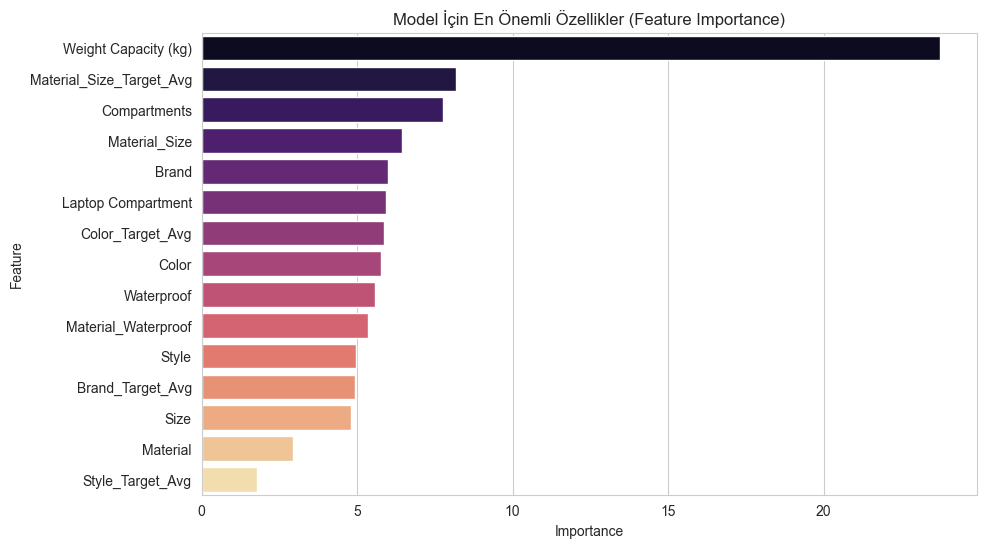

In [31]:
# Modelin en çok önem verdiği özellikleri görelim
feature_importance = model_cat.get_feature_importance()
feature_names = x_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Model İçin En Önemli Özellikler (Feature Importance)')
plt.show()

In [32]:
importance_df

,Feature,Importance
8,Weight Capacity (kg),23.724848
13,Material_Size_Target_Avg,8.194145
3,Compartments,7.768909
10,Material_Size,6.439557
0,Brand,5.981530
4,Laptop Compartment,5.918894
14,Color_Target_Avg,5.877454
7,Color,5.773858
5,Waterproof,5.577969
9,Material_Waterproof,5.335296


In [33]:
# 1. Tahminleri al
y_train_tahmin = model_cat.predict(x_train)
y_test_tahmin = model_cat.predict(x_test)

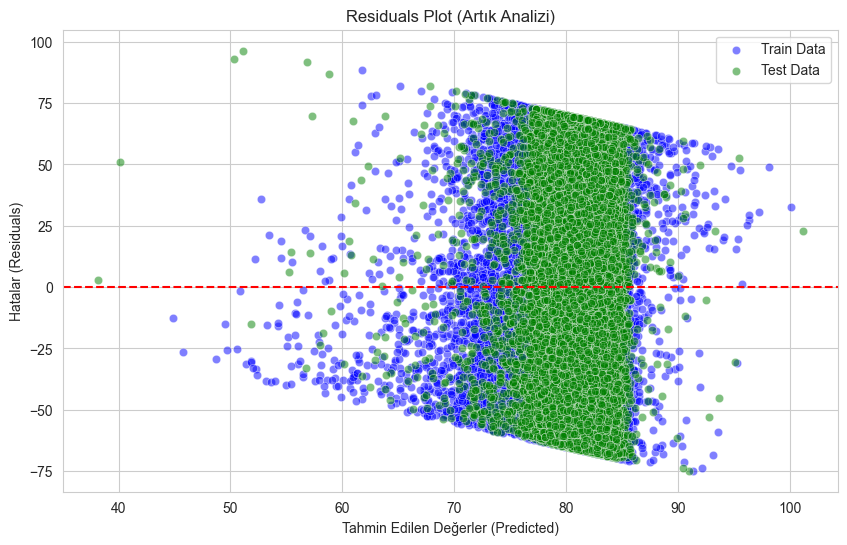

In [34]:
# 2. Residuals (Artıkları) hesapla
train_residuals = y_train - y_train_tahmin
test_residuals = y_test - y_test_tahmin

# 3. Görselleştirme
plt.figure(figsize=(10, 6))

# Eğitim verisi artıkları
sns.scatterplot(x=y_train_tahmin, y=train_residuals, color="blue", alpha=0.5, label="Train Data")
# Test verisi artıkları
sns.scatterplot(x=y_test_tahmin, y=test_residuals, color="green", alpha=0.5, label="Test Data")

# Sıfır çizgisi (İdeal durum)
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residuals Plot (Artık Analizi)')
plt.xlabel('Tahmin Edilen Değerler (Predicted)')
plt.ylabel('Hatalar (Residuals)')
plt.legend()
plt.show()

<Axes: xlabel='Price', ylabel='Density'>

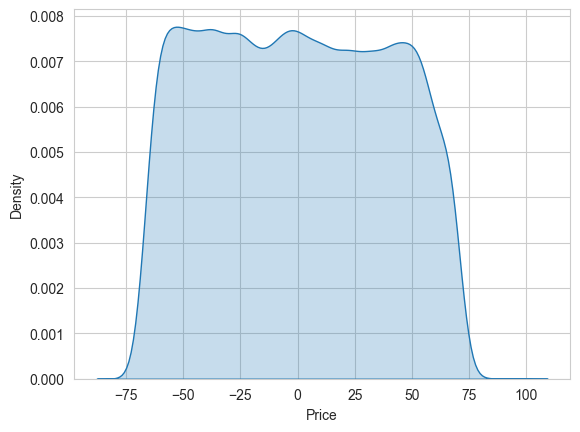

In [35]:
# Kalıntıları (residuals) hesapla ve yoğunluk grafiğini çiz
residuals = y_test - model_cat.predict(x_test)
sns.kdeplot(residuals, fill=True)

In [39]:
# 1. Test verisi için tahmin yap (CatBoost otomatik olarak seçtiğimiz özellikleri kullanır)

final_preds = model_cat.predict(test.drop('id', axis=1))

# 2. Dosyayı oluştur
submission = pd.DataFrame({
    'id': test['id'],
    'Price': final_preds
})

submission.to_csv('catboost_target_encoded_3889.csv', index=False)

In [38]:
# Modeli dışarı aktaralım
model_cat.save_model("catboost_backpack_model.cbm")

# Sonuç

1. **Verinin Ruhunu Anlamak (EDA):** Önce veriye sorular sorduk: "Ağır yük taşıyan çantalar her zaman daha mı pahalı?", "Su geçirmezlik fiyatı ne kadar etkiliyor?" Bu aşamada `Weight Capacity` özelliğinin fiyatın en büyük dostu olduğunu keşfettik.
2. **Özellikleri Konuşturmak (Feature Engineering):** Sadece ham veriye güvenmedik. Malzeme ve Boyutun etkileşimini (`Material_Size`) hesaplayarak modele yeni ipuçları verdik. Markaların ve renklerin ortalama fiyatlarını (`Target Encoding`) kullanarak kategorik verileri sayısal birer güce dönüştürdük.
3. **Zekice Tahmin (Modeling):** Karmaşık ve kategorik verilerde uzman olan **CatBoost** algoritmasını seçtik. Bu model, çantaların özelliklerini tek tek değil, bir bütün olarak değerlendirip en tutarlı fiyatı bulmamızı sağladı.
4. **Hatalardan Ders Çıkarmak (Evaluation):** Tahminlerimizin gerçek fiyatlardan ne kadar saptığını ölçtük. Elde ettiğimiz **38.89 RMSE** skoru ve çizdiğimiz hata grafikleri (Residual Plots), modelimizin ne kadar dürüst ve kararlı olduğunu kanıtladı.
